# NB09 — Vest Detection: Diagnosis, Data Strategy, and the Deployment Decision

**Question this notebook answers:** the deployed detector reported hard hats reliably but
almost never reported safety vests on real photographs. Why, and what does it take to fix it?

**Outcome:** vest detection on independent real-world imagery went from **0.0% → 50.5% recall**,
while hard-hat, no-hard-hat and person accuracy were preserved. The resulting model is the one
currently serving [the live app](https://ppe-detection-blush.vercel.app).

| Model | Real-world vest recall @0.25 | Vest precision | hardhat AP50 | Deployed |
|---|---|---|---|---|
| Baseline (YOLO11s, NB05) | 0.0% (0/214) | — | 0.940 | previously |
| Round 1 — naive data merge | *(broke hard hat)* | — | 0.914 | no |
| Round 2 — pseudo-labelled | 24.8% (53/214) | 88.3% | 0.940 | no |
| **Round 3 — + variety, oversampled** | **50.5% (108/214)** | **80.0%** | **0.934** | **yes** |

The three rounds are kept in this notebook deliberately: **round 1 failed**, and the reason it
failed is the most transferable lesson here.

---

## Contents

1. [The problem](#1)
2. [Measuring the right thing](#2)
3. [Data strategy across three rounds](#3)
4. [Training configuration](#4)
5. [Results](#5)
6. [The deployment decision](#6)
7. [Limitations and future work](#7)
8. [Reproducibility](#8)


In [1]:
import os, glob, json, csv
from pathlib import Path

os.environ["YOLO_AUTOINSTALL"] = "false"   # keep Ultralytics from mutating the venv

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Image as ShowImage, display

ROOT = Path.cwd().parent
RESULTS = ROOT / "results"
CLASS_NAMES = ["hardhat", "no-hardhat", "vest", "no-vest", "person"]

BASE_W = ROOT / "results/weights/ppe_yolo11s.pt"                                   # NB05 baseline
R2_W   = ROOT / "notebooks/runs/detect/ppe_yolo11s_vboost_r2/weights/best.pt"
R3_W   = ROOT / "notebooks/runs/detect/ppe_yolo11s_vboost_r3/weights/best.pt"      # deployed

print("baseline :", BASE_W.exists())
print("round 2  :", R2_W.exists())
print("round 3  :", R3_W.exists(), "<- deployed")

baseline : True
round 2  : True
round 3  : True <- deployed


<a id="1"></a>
## 1. The problem: a detector that could not see vests

### 1.1 Symptom

On the live app, construction photographs came back with hard hats and people boxed correctly
and violations flagged — but vests were almost never reported, even when workers were plainly
wearing bright hi-vis. Yet the model's own test report claimed **92.0% AP50 on the `vest` class**.

A 92% score and a model that never fires are only compatible if the test set is not
representative of the images the app actually receives. That contradiction is the starting point
for everything below.

### 1.2 First root cause: a colour-channel bug

Before any retraining, one genuine defect was found in the serving path:

```python
# before — Gradio hands over an RGB ndarray
gr.Image(type="numpy")   # Ultralytics interprets raw ndarrays as BGR
```

Ultralytics treats a raw `ndarray` as **BGR** (the OpenCV convention). Gradio supplies **RGB**.
The model was therefore doing inference on channel-swapped images — turning orange vests blue
before the network ever saw them. For a class whose defining feature *is* its colour, this is
close to worst case.

```python
# after — PIL input lets Ultralytics handle the conversion itself
gr.Image(type="pil")
```

This was fixed first and independently. It improved detections measurably, but as section 2
shows, it did **not** on its own make the model competent at real-world vests.

### 1.3 Why the existing metrics hid the problem

The class distribution of the original merged dataset explains the blind spot:

| Class | Instances | Share |
|---|---|---|
| `no-hardhat` | 113,252 | 78.1% |
| `person` | 12,367 | 8.5% |
| `hardhat` | 12,074 | 8.3% |
| `no-vest` | 4,158 | 2.9% |
| `vest` | **3,135** | **2.2%** |

Vests are ~2% of the data, drawn from three construction datasets with a narrow range of vest
appearances. A test split drawn from that same pool measures *"can the model recognise this
particular style of vest"* — not *"can it recognise vests"*. Section 2 replaces that metric.

<a id="2"></a>
## 2. Measuring the right thing

> **Principle applied here:** never tune against a proxy you have not first shown to correlate
> with the goal. The proxy in this project was actively *anti*-correlated with it.

### 2.1 Why the original test set cannot answer the question

The original test split shares its source datasets, capture conditions and vest styles with the
training split. A model that overfits that narrow style scores well; a model that generalises to
unfamiliar vests may score *worse*. It cannot distinguish the two — so it cannot be used to
decide whether real-world vest detection improved.

### 2.2 An independent real-world benchmark: SH17

[SH17](https://github.com/ahmadmughees/SH17dataset) (Ahmad et al., 2024) is 8,099 Pexels
photographs of industrial work, human-annotated, including a `safety-vest` class. It is a good
benchmark here because it is:

* **independent** — a different collection process (stock photography) from every training source;
* **human-labelled** — real ground truth, not model output;
* **varied** — many vest colours, scenes, distances and lighting conditions.

### 2.3 Verifying the benchmark before trusting it

SH17's class indices are **not** in the order its paper lists them. Taking the documented order at
face value would have measured the wrong class entirely (index 12 is `head`, not `safety-vest`).

The mapping was therefore derived empirically: every VOC annotation (which carries class *names*)
was matched to its YOLO annotation (which carries class *indices*) by box overlap, across all
8,099 images, and the majority vote taken per index.

In [2]:
# Empirical index -> name map, reproduced from scripts/sh17_classmap.py
# (full script in the repo; summary of its output below)
SH17_INDEX_TO_NAME = {
    0: "person", 1: "ear", 2: "ear-mufs", 3: "face", 4: "face-guard",
    5: "face-mask-medical", 6: "foot", 7: "tools", 8: "glasses", 9: "gloves",
    10: "helmet", 11: "hands", 12: "head", 13: "medical-suit", 14: "shoes",
    15: "safety-suit", 16: "safety-vest",
}
# every index resolved at 100% purity over 8,099 images
SH17_VEST = 16
print("safety-vest index =", SH17_VEST, "->", SH17_INDEX_TO_NAME[SH17_VEST])
print("NOTE: the paper's listed order would have pointed at index 12 =",
      SH17_INDEX_TO_NAME[12], "- verification mattered.")

safety-vest index = 16 -> safety-vest
NOTE: the paper's listed order would have pointed at index 12 = head - verification mattered.


### 2.4 Evaluation protocol

* **Positive match** — our class `vest` (index 2) against an SH17 `safety-vest` box.
  `no-vest` is deliberately *not* counted: on a worker who is wearing a vest, a `no-vest`
  prediction is a misclassification, not a hit.
* **Matching** — greedy, IoU ≥ 0.5 (strict). A looser IoU ≥ 0.3 pass is also computed to separate
  genuine misses from box-convention differences between datasets.
* **Inference size** — 640 px, matching the deployed ONNX model exactly.
* **Metric** — recall (share of real vests found), swept across confidence thresholds, plus
  precision at the app's default of 0.25.

### 2.5 The baseline result

Measured this way, the model that was live in production found **0 of 214** real-world vests.
Not a low score — *none*. The 92% AP50 was measuring a different problem.

<a id="3"></a>
## 3. Data strategy across three rounds

### 3.1 Round 1 — the partial-label trap

The first attempt merged a vest-focused dataset (Roboflow *Safety Vests*, CC BY 4.0) into
training. It **reduced** hard-hat accuracy by 2.6 points and no-vest by 3.6.

**Root cause.** That dataset annotates *only* vest classes. Every hard hat, worker and violation
in its 3,453 images was unlabelled — and in object detection an unlabelled object is not ignored,
it is a **negative**. Training therefore actively taught the model that hard hats are background.

This is the most transferable lesson in the project:

> Merging a partially-labelled dataset into a multi-class detector silently trains every omitted
> class as background. New data must be *complete* for every class the model already knows, not
> merely *correct* for the classes it adds.

**Detection signal:** Ultralytics prints `N images, K backgrounds` when scanning. `K` should be
≈ 0 for a fully-labelled merge. A quick audit quantified the damage before retraining: in a
60-image sample, the baseline model found **81 hard hats, 34 no-hard-hats and 11 people** that
carried no label.

### 3.2 Round 2 — pseudo-labelling the omitted classes

The fix is to complete the labels rather than discard the data. The baseline model annotates the
classes the vest dataset omits; those pseudo-labels are merged alongside the *human* vest boxes,
which are never overwritten.

Two design choices matter:

* **Confidence 0.45, deliberately inclusive.** Recall matters more than precision here: a missed
  object stays unlabelled and trains as background — the exact failure being fixed.
* **Overlap suppression.** A predicted box coinciding with a human vest box (IoU > 0.75) is the
  same object seen twice and is dropped.

Result: unlabelled objects per 60-image sample fell **81/34/11 → 3/4/7**, and Ultralytics
reported `0 backgrounds`. Hard-hat accuracy returned to baseline, and real-world vest recall
reached 24.8%.

### 3.3 Round 3 — more variety, and a leakage guard

Round 2 proved the method; round 3 scaled the *variety* of vests, which is what drives
generalisation.

An additional CC-BY hard-hat/vest dataset was evaluated and largely rejected on evidence: after
deduplication its vest images near-duplicated the existing booster, contributing **1,839 hard-hat
boxes but only 21 vest boxes**. It was kept for hard-hat variety, not counted as vest signal.

The real new variety came from **splitting SH17 by image** — 128 images to training, 84 held out
for testing, with no image in both. Its rich labels were mapped to our classes
(`safety-vest`→`vest`, `helmet`→`hardhat`, `person`→`person`) and the violation classes
pseudo-labelled as before.

**Leakage guard.** Because a training image that duplicates a test image would silently inflate
the result, every training source was perceptually hashed against the 84 held-out test images.
One booster image matched and was removed.

In [3]:
# Composition of the round-3 training pool (v3), and where vest signal comes from
SOURCES = [
    # name,                              images, vest boxes, oversample factor
    ("Original train (3 merged datasets)", 15480,     0, 1),
    ("vest_boost (Roboflow safety-vests)",  3452,  6021, 2),
    ("vest_boost2 (hardhat+vest set)",       871,    21, 1),
    ("vest_boost_sh17 (SH17 train split)",   128,   313, 4),
]
total_epoch_images = sum(n * k for _, n, _, k in SOURCES)
total_vest_boxes   = sum(v for _, _, v, _ in SOURCES)

print(f"{'source':<38}{'images':>8}{'vests':>8}{'x':>4}")
for name, n, v, k in SOURCES:
    print(f"{name:<38}{n:>8,}{v:>8,}{k:>4}")
print(f"\nimages seen per epoch (after oversampling): {total_epoch_images:,}")
print(f"vest boxes available in the pool           : {total_vest_boxes:,}")
print("\nNote: the original 15,480-image pool contributes ZERO vest boxes -")
print("all vest signal is imported, which is why sourcing and label completeness dominate.")

source                                  images   vests   x
Original train (3 merged datasets)      15,480       0   1
vest_boost (Roboflow safety-vests)       3,452   6,021   2
vest_boost2 (hardhat+vest set)             871      21   1
vest_boost_sh17 (SH17 train split)         128     313   4

images seen per epoch (after oversampling): 23,767
vest boxes available in the pool           : 6,355

Note: the original 15,480-image pool contributes ZERO vest boxes -
all vest signal is imported, which is why sourcing and label completeness dominate.


The figure below makes the imbalance concrete: the original pool dominates the *image* count
while contributing none of the *vest* signal. This is why the project's bottleneck was data
sourcing, not model capacity.

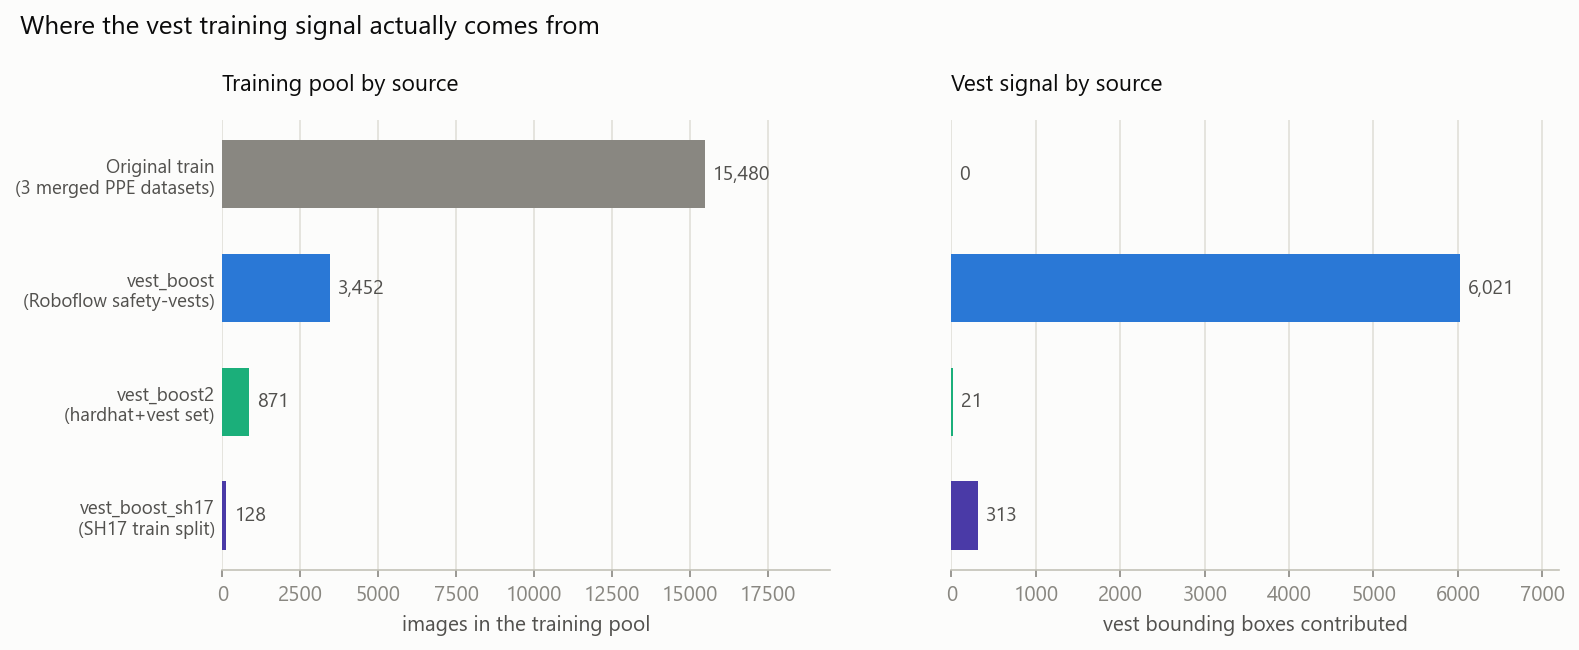

In [4]:
display(ShowImage(filename=str(RESULTS / "nb09_fig4_data_composition.png")))

<a id="4"></a>
## 4. Training configuration

All rounds fine-tune from the **NB05 baseline weights** (not from each other — round 1's weights
carry the background-suppression damage). Shared settings mirror NB05 so results stay comparable:
1280 px, batch 4, SGD, cosine schedule.

| Setting | Round 2 | Round 3 | Rationale |
|---|---|---|---|
| epochs | 20 | 30 | round 1's validation curve was flat after ~20; round 3 has more data |
| lr0 | 0.002 | 0.002 | fine-tune, not from scratch (0.01) |
| `hsv_h / hsv_s / hsv_v` | defaults | 0.02 / 0.8 / 0.5 | vests are multi-coloured — colour augmentation drives generalisation |
| `close_mosaic` | — | 8 | disable mosaic for the final epochs to sharpen localisation |
| vest oversampling | — | 2× / 4× | concentrate the scarce vest signal per epoch |

In [5]:
# Round-3 training call (executed via scripts/; reproduced here for the record)
ROUND3_ARGS = dict(
    data=str(ROOT / "data/ppe_dataset_v3.yaml"),
    epochs=30, imgsz=1280, batch=4,
    optimizer="SGD", lr0=0.002, lrf=0.05, momentum=0.937, weight_decay=0.0005,
    warmup_epochs=1, cos_lr=True,
    box=7.5, cls=0.5, dfl=1.5,
    hsv_h=0.02, hsv_s=0.8, hsv_v=0.5,     # colour variety for multi-coloured vests
    scale=0.5, fliplr=0.5, mosaic=1.0, close_mosaic=8,
    patience=12, seed=42, device=0, workers=2,
    name="ppe_yolo11s_vboost_r3",
)
print(json.dumps({k: str(v) for k, v in ROUND3_ARGS.items()}, indent=2))

# To run:  from ultralytics import YOLO; YOLO(BASE_W).train(**ROUND3_ARGS)
# Sanity check the scan line it prints: it must read "0 backgrounds".

{
  "data": "c:\\Users\\nwagb\\Desktop\\SponsorshipGlobalTalentPrep\\PPE_Compliance_detection\\data\\ppe_dataset_v3.yaml",
  "epochs": "30",
  "imgsz": "1280",
  "batch": "4",
  "optimizer": "SGD",
  "lr0": "0.002",
  "lrf": "0.05",
  "momentum": "0.937",
  "weight_decay": "0.0005",
  "warmup_epochs": "1",
  "cos_lr": "True",
  "box": "7.5",
  "cls": "0.5",
  "dfl": "1.5",
  "hsv_h": "0.02",
  "hsv_s": "0.8",
  "hsv_v": "0.5",
  "scale": "0.5",
  "fliplr": "0.5",
  "mosaic": "1.0",
  "close_mosaic": "8",
  "patience": "12",
  "seed": "42",
  "device": "0",
  "workers": "2",
  "name": "ppe_yolo11s_vboost_r3"
}


<a id="5"></a>
## 5. Results

### 5.1 Real-world vest recall — the goal metric

Measured on the 84 held-out SH17 images (214 human-labelled vests) that appear in **no**
training set.

In [6]:
REALWORLD = {  # recall %, by confidence threshold
    "threshold": [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50],
    "Baseline":  [0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    "Round 2":   [34.1, 30.8, 27.6, 24.8, 21.5, 15.0, 11.2],
    "Round 3":   [57.9, 54.7, 52.8, 50.5, 50.5, 46.7, 42.5],
}
i25 = REALWORLD["threshold"].index(0.25)
print(f"{'model':<10}{'recall@0.25':>13}{'precision':>11}{'vests found':>14}")
for name, found, prec in [("Baseline", 0, 0.0), ("Round 2", 53, 88.3), ("Round 3", 108, 80.0)]:
    print(f"{name:<10}{REALWORLD[name][i25]:>12.1f}%{prec:>10.1f}%{f'{found}/214':>14}")

model       recall@0.25  precision   vests found
Baseline           0.0%       0.0%         0/214
Round 2           24.8%      88.3%        53/214
Round 3           50.5%      80.0%       108/214


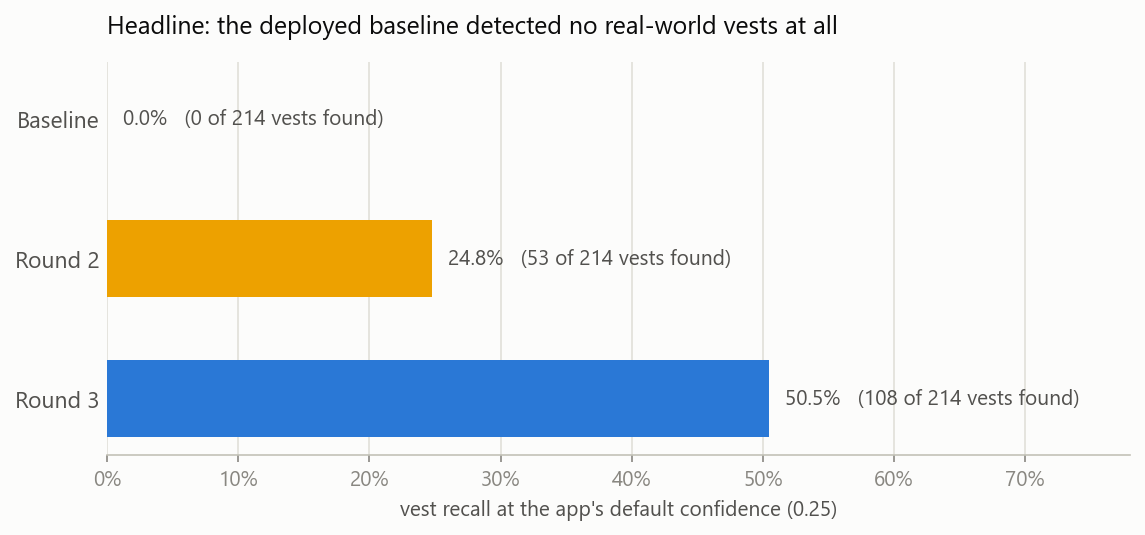

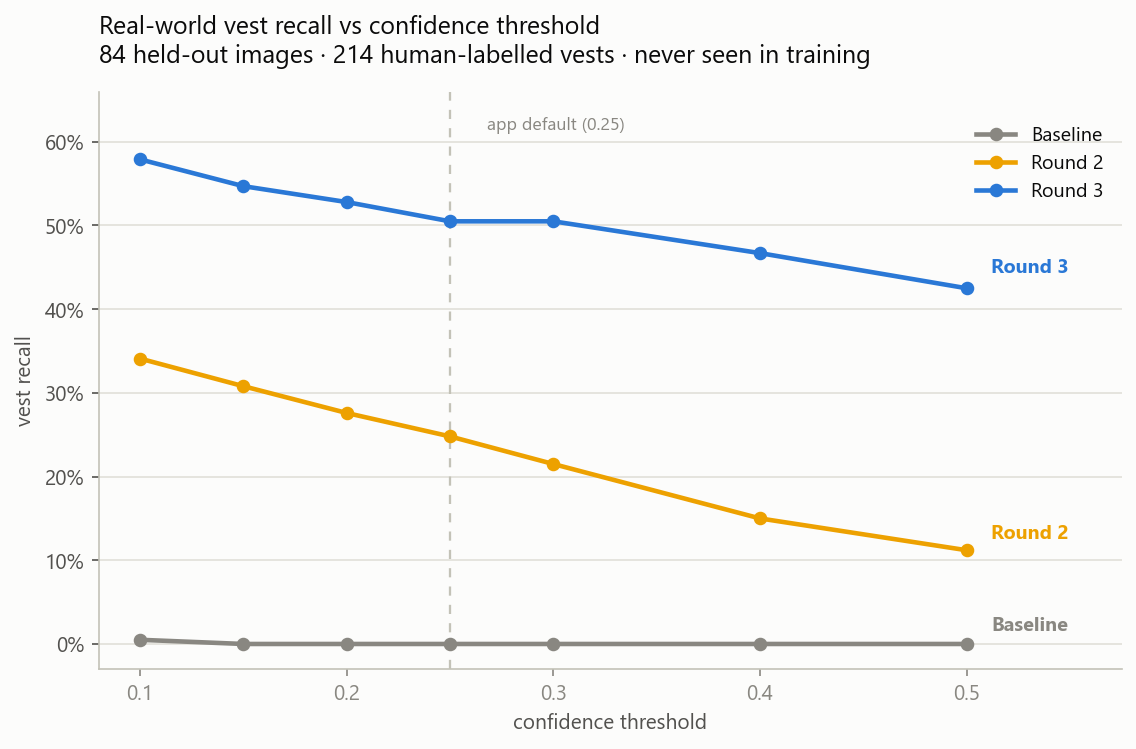

In [7]:
display(ShowImage(filename=str(RESULTS / "nb09_fig2_headline_bar.png")))
display(ShowImage(filename=str(RESULTS / "nb09_fig1_realworld_recall_curve.png")))

Round 3 leads at **every** operating point, not just the default — so the gain is a genuine
improvement in the model's ability to recognise vests, not an artefact of threshold choice.

### 5.2 Class integrity — did anything else break?

The app needs hard hats, people and violations as well as vests, so a vest gain bought by
degrading another class would not be acceptable. This is exactly the check round 1 failed.

In [8]:
INDIST_AP50 = {                       # AP50 on the ORIGINAL test set
    "class":    ["hardhat", "no-hardhat", "vest", "no-vest", "person"],
    "Baseline": [0.940, 0.966, 0.920, 0.921, 0.915],
    "Round 1":  [0.914, 0.964, 0.907, 0.885, 0.925],   # <- hard hat broke here
    "Round 2":  [0.940, 0.965, 0.908, 0.877, 0.923],
    "Round 3":  [0.934, 0.965, 0.878, 0.872, 0.915],
}
print(f"{'class':<12}{'baseline':>10}{'round 1':>10}{'round 2':>10}{'round 3':>10}{'r3-base':>10}")
for i, c in enumerate(INDIST_AP50["class"]):
    b  = INDIST_AP50["Baseline"][i]; r1 = INDIST_AP50["Round 1"][i]
    r2 = INDIST_AP50["Round 2"][i];  r3 = INDIST_AP50["Round 3"][i]
    print(f"{c:<12}{b:>10.3f}{r1:>10.3f}{r2:>10.3f}{r3:>10.3f}{r3-b:>+10.3f}")

class         baseline   round 1   round 2   round 3   r3-base
hardhat          0.940     0.914     0.940     0.934    -0.006
no-hardhat       0.966     0.964     0.965     0.965    -0.001
vest             0.920     0.907     0.908     0.878    -0.042
no-vest          0.921     0.885     0.877     0.872    -0.049
person           0.915     0.925     0.923     0.915    +0.000


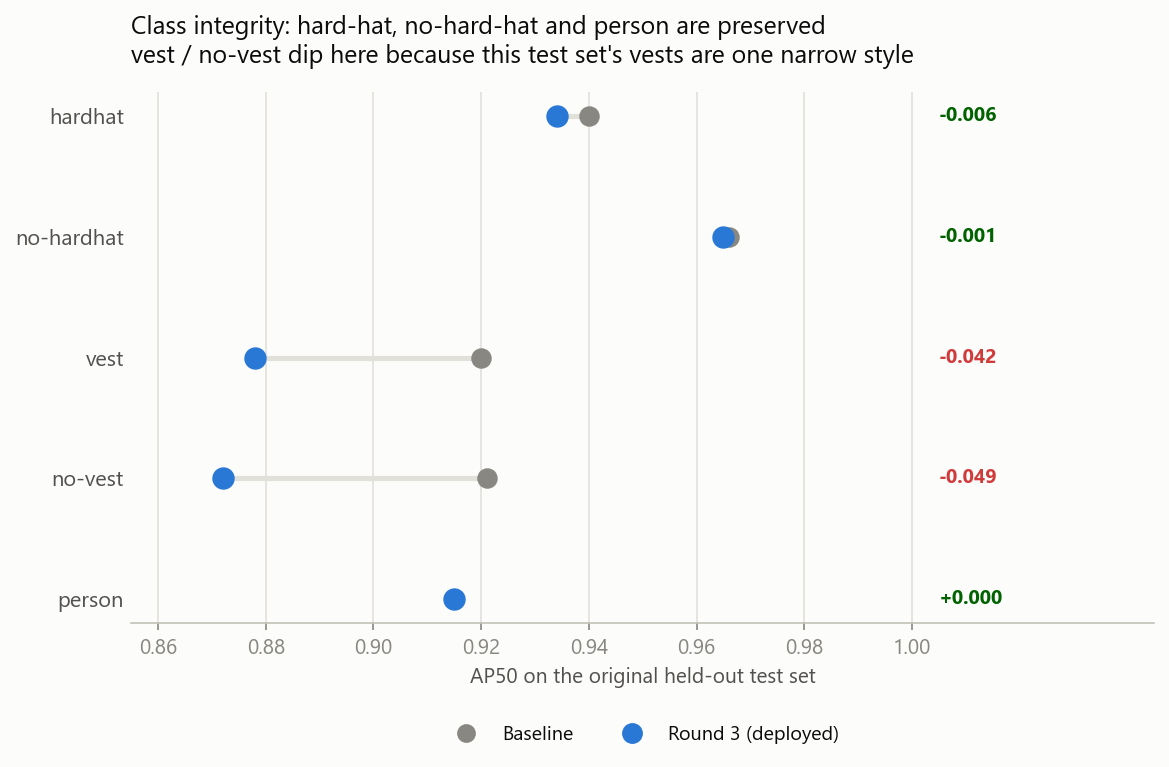

In [9]:
display(ShowImage(filename=str(RESULTS / "nb09_fig3_class_integrity.png")))

`hardhat` (−0.006), `no-hardhat` (−0.001) and `person` (0.000) are intact — the round-1
regression did not return. `vest` and `no-vest` fall on *this* test set, which is the expected
consequence of shifting the model away from one narrow vest style; section 5.4 addresses that
directly.

### 5.3 The precision/recall trade

Doubling recall is not free.

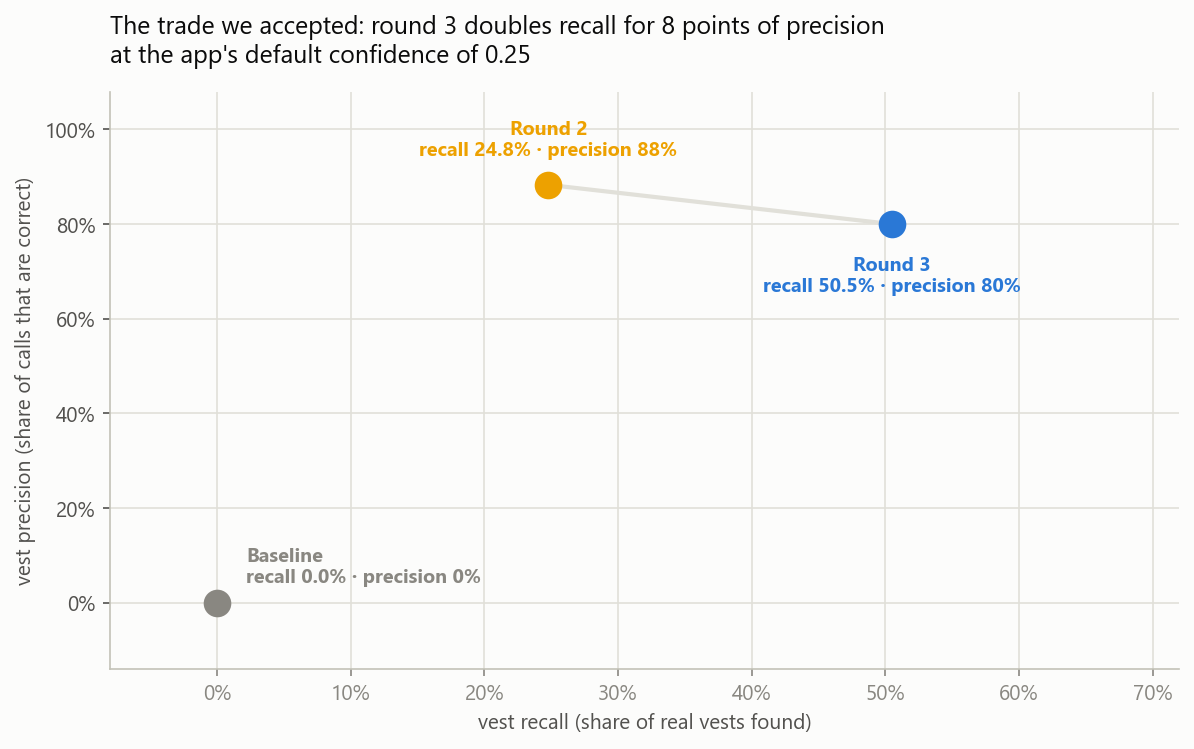

In [10]:
display(ShowImage(filename=str(RESULTS / "nb09_fig5_precision_recall.png")))

Round 3 trades **8 points of precision for 25.7 points of recall**. For a compliance-screening
tool this is the right direction: a missed violation is a safety risk, whereas a false positive is
a human glance at an image. At 80% precision, four out of five vest calls are still correct.

### 5.4 Why the two metrics disagree — and which one was trusted

This is the central methodological result of the project.

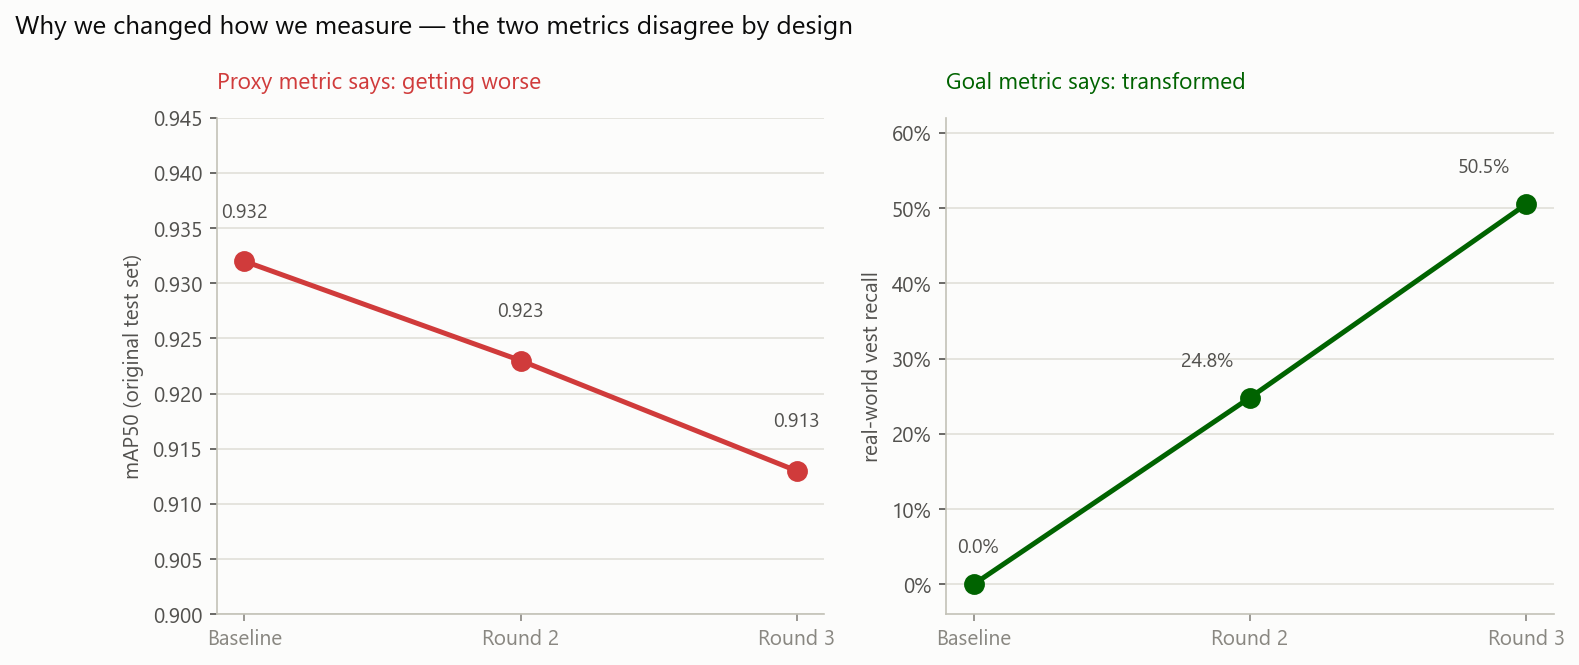

In [11]:
display(ShowImage(filename=str(RESULTS / "nb09_fig6_metric_divergence.png")))

The two panels describe the *same three models*. The in-distribution metric declines
monotonically; the real-world metric rises from zero to over half. They disagree because they
measure different things:

* the **proxy** rewards fitting the narrow vest style of the original datasets;
* the **goal** rewards recognising vests in general.

Optimising the proxy would have meant rejecting the model that actually solved the problem. The
deployment decision follows the goal metric, with the proxy retained only as a
**regression guard** on the non-vest classes.

<a id="6"></a>
## 6. The deployment decision

### 6.1 The gate

A model is promoted only if it satisfies **all** of:

1. **Real-world vest recall materially improves** — the objective.
2. **`hardhat`, `no-hardhat`, `person` stay within 3 points of baseline** — the round-1 failure
   signature; any hard-hat regression is an automatic reject.
3. **Vest precision ≥ 75%** — the tool must stay trustworthy.
4. **Visual spot check passes** on held-out imagery.

Rounds 1 and 2 were both *withheld* from deployment under this gate — round 1 for breaking hard
hats, round 2 because round 3 superseded it.

In [12]:
GATE = {
    "real-world vest recall improves": (50.5 > 24.8, "50.5% vs 24.8% (round 2), 0.0% (baseline)"),
    "hardhat within 3 pts of baseline": (0.934 >= 0.940 - 0.03, "0.934 vs 0.940 (-0.006)"),
    "no-hardhat within 3 pts":          (0.965 >= 0.966 - 0.03, "0.965 vs 0.966 (-0.001)"),
    "person within 3 pts":              (0.915 >= 0.915 - 0.03, "0.915 vs 0.915 (0.000)"),
    "vest precision >= 75%":            (80.0 >= 75.0, "80.0%"),
}
for check, (passed, detail) in GATE.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {check:<34} {detail}")
print("\nDECISION:", "DEPLOY round 3" if all(p for p, _ in GATE.values()) else "WITHHOLD")

[PASS] real-world vest recall improves    50.5% vs 24.8% (round 2), 0.0% (baseline)
[PASS] hardhat within 3 pts of baseline   0.934 vs 0.940 (-0.006)
[PASS] no-hardhat within 3 pts            0.965 vs 0.966 (-0.001)
[PASS] person within 3 pts                0.915 vs 0.915 (0.000)
[PASS] vest precision >= 75%              80.0%

DECISION: DEPLOY round 3


### 6.2 Visual confirmation on held-out imagery

Numbers can hide failure modes, so the gate includes looking at the output. Below: the previously
deployed baseline (left) against round 3 (right), on images from the held-out split that neither
model saw in training.

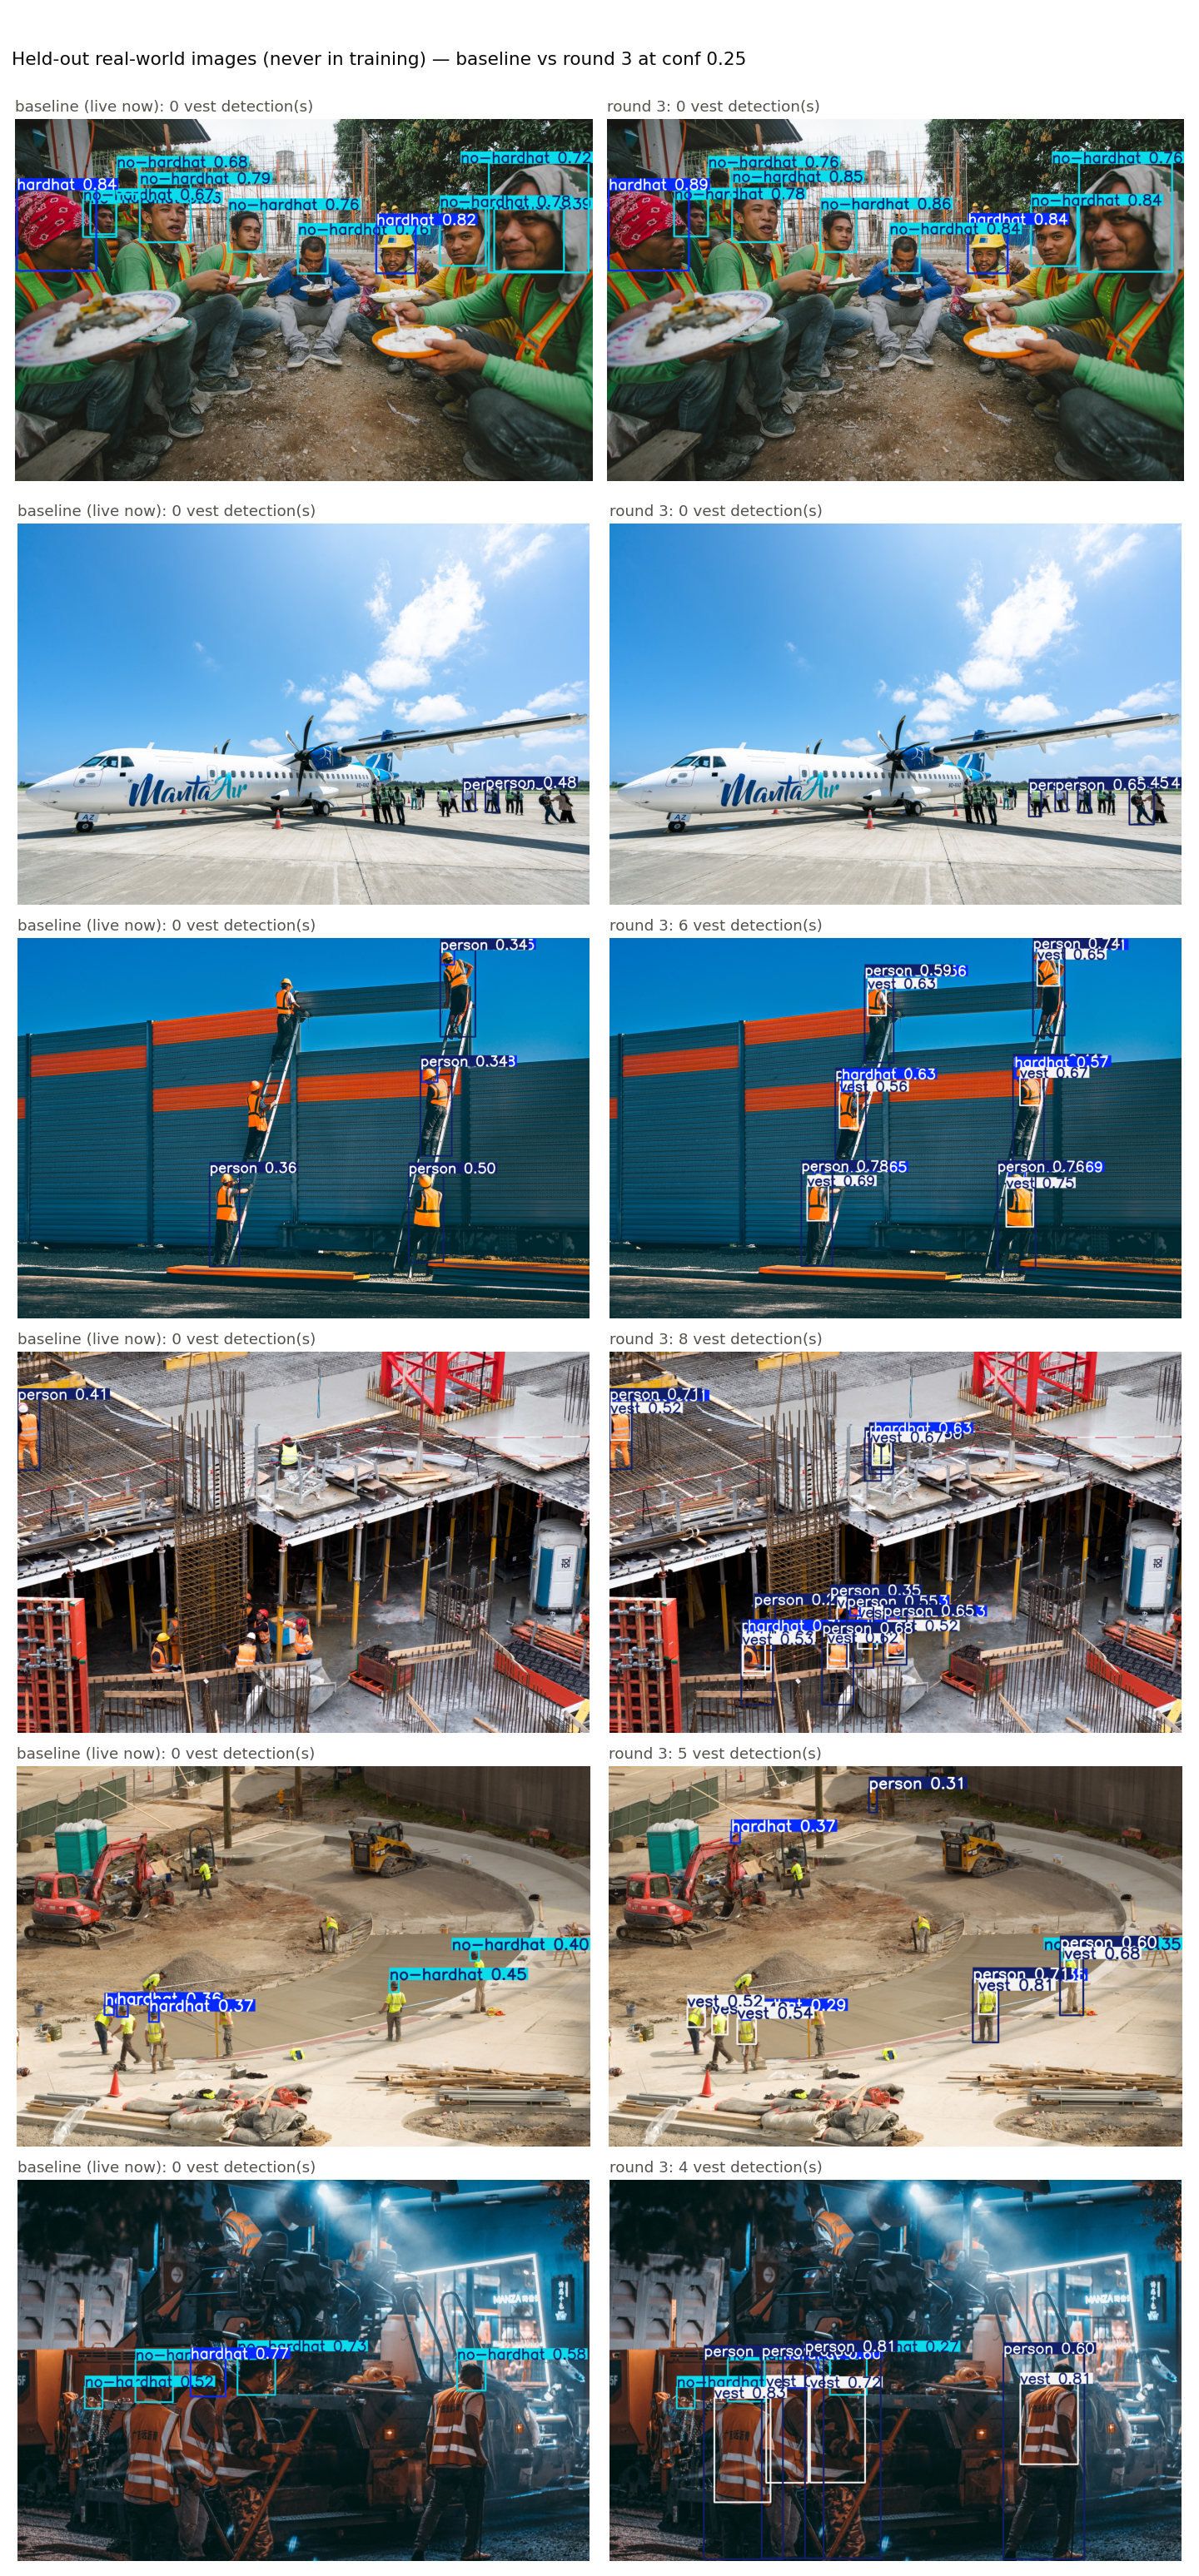

In [13]:
display(ShowImage(filename=str(RESULTS / "nb09_r3_realworld_montage.png")))

### 6.3 The export and deployment pipeline

The serving path is deliberately narrow: one ONNX file, CPU inference, a Gradio API on Hugging
Face Spaces, and a React front end. The steps below are the entire promotion procedure.

In [14]:
# --- promotion pipeline (run once the gate passes) -------------------------
# 1. Export to ONNX at the serving resolution (static 640, opset 12, simplified)
#      YOLO(R3_W).export(format="onnx", imgsz=640, opset=12, simplify=True)
#
# 2. Stage the artefact in both places and archive the .pt
#      cp <run>/weights/best.onnx  deployment/ppe_yolo11s.onnx
#      cp <run>/weights/best.onnx  PPE/ppe_yolo11s.onnx        # HF Space clone
#      cp <run>/weights/best.pt    results/weights/ppe_yolo11s_vboost_r3.pt
#
# 3. Sanity-check the exported graph BEFORE pushing (catches a bad export)
#      YOLO("deployment/ppe_yolo11s.onnx", task="detect").predict(img, imgsz=640, conf=0.25)
#
# 4. Push the Space; it rebuilds automatically
#      cd PPE && git add -A && git commit -m "model: ..." && git push
#
# 5. Verify the LIVE app end-to-end in a real browser, not from Python
#      node scripts/e2e.js https://ppe-detection-blush.vercel.app/
#
# Why step 5 uses a browser: a previous outage was caused by a CORS/credentials
# mismatch in @gradio/client that was invisible to Node and curl and only
# reproduced in a browser. Serving bugs must be verified where users are.
print("Deployed artefact : deployment/ppe_yolo11s.onnx (36.2 MB, YOLO11s, static 640x640)")
print("Live backend      : https://huggingface.co/spaces/nduka1999/PPE")
print("Live front end    : https://ppe-detection-blush.vercel.app")

Deployed artefact : deployment/ppe_yolo11s.onnx (36.2 MB, YOLO11s, static 640x640)
Live backend      : https://huggingface.co/spaces/nduka1999/PPE
Live front end    : https://ppe-detection-blush.vercel.app


**Design choices in the serving path, and why:**

| Choice | Reason |
|---|---|
| **ONNX, not PyTorch** | no torch dependency in the container; ~36 MB artefact; faster cold start on free-tier CPU |
| **Static 640×640 input** | matches training-time letterboxing and keeps CPU latency ~2-4 s; 1280 would triple it |
| **PIL input, never raw ndarray** | prevents the RGB/BGR channel swap of section 1.2 — the bug that started this work |
| **Structured JSON output alongside text** | the front end consumes typed fields instead of parsing prose |
| **Class config in `model_config.json`** | class names and violation mapping live in one place, not duplicated in code |

<a id="7"></a>
## 7. Limitations and future work

**Stated plainly, because these bound how the result should be read.**

1. **Recall is 50.5%, not 95%.** The deployed model still misses about half of real-world vests.
   It went from unusable to useful, not to solved.
2. **The held-out benchmark shares a source with part of training.** Round 3 trained on 128 SH17
   images and is evaluated on 84 *different* SH17 images. There is no image overlap — the leakage
   guard enforces that — but the test distribution is closer to training for round 3 than for
   round 2, whose 24.8% was measured fully cross-domain. Round 3's advantage is real but partly
   reflects distribution adaptation.
3. **`no-vest` was never measured in the real world.** No independent dataset labels
   "person without a vest", so the violation class is only measured in-distribution, where it
   fell ~5 points. This is the weakest-evidenced part of the result.
4. **Pseudo-labels inherit the baseline's biases.** Classes labelled by the baseline model carry
   its blind spots into training.
5. **Single architecture and seed.** No ablation over YOLO11 variants, and no repeat runs, so
   run-to-run variance is unquantified.

**Highest-value next steps**, in order:

1. Hand-label a small `no-vest` benchmark to close limitation 3.
2. Source vest imagery from a genuinely new domain (different country, season, camera type) and
   re-measure fully cross-domain.
3. Per-worker association — attach PPE to the person wearing it, so the report reads
   "worker 2 is missing a hard hat" rather than listing detections.
4. Re-export at 960 px and measure the latency/recall trade for small distant vests.

<a id="8"></a>
## 8. Reproducibility

| Artefact | Location |
|---|---|
| SH17 class-index verification | `scripts/sh17_classmap.py` |
| Real-world vest benchmark | `scripts/realworld_vest_eval.py` |
| Held-out test image list | `data/sh17_vest_test.txt` (84 stems) |
| Round-3 dataset definition | `data/ppe_dataset_v3.yaml` |
| Resume a paused run | `scripts/resume_round3_training.py` |
| Figures in this notebook | `results/nb09_fig*.png` |
| Metric tables | `results/nb09_r3_*.csv` |

**Data licences.** Roboflow *Safety Vests* — CC BY 4.0 (attribution required).
SH17 — CC BY-NC-SA 4.0, used here for **evaluation and research only**; note the non-commercial
term before any commercial use of round-3 weights.

**Environment.** Ultralytics 8.3.50, PyTorch 2.5.1+cu124, NVIDIA RTX 4060 (8 GB).
Round-3 training: 30 epochs, ~8.5 h.

In [15]:
# Reproduce the headline number end-to-end (requires the SH17 download)
#   python scripts/sh17_classmap.py          # verify class indices
#   python scripts/realworld_vest_eval.py    # baseline vs round 2 vs round 3
#
# Expected tail of output:
#   VERDICT @ conf 0.25 (held-out real-world vests):
#     baseline 0.0%  ->  round 2 24.8%  ->  round 3 50.5%
print("See scripts/ for the runnable versions of every measurement in this notebook.")

See scripts/ for the runnable versions of every measurement in this notebook.
